In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

In [5]:
train = pd.read_csv('train.csv')

C:\Users\MSI\AppData\Local\Temp\ipykernel_16776\2949129822.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train.csv')


In [8]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [10]:
test = pd.read_csv('test.csv')
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [16]:
train.shape

(1017209, 9)

In [22]:
print(f"Hec satis etmeyenlerin percentage i : {((train['Sales'] == 0).sum() / len(train['Sales']) * 100).__round__(2)} %")

Hec satis etmeyenlerin percentage i : 16.99 %


In [ ]:
print(((train['Sales'] == 0) & (train['Open'] == 1)).sum())
#54 dene aciq lakin satis etmeyen 
print(((train['Sales'] == 0) & (train['Open'] == 0)).sum())
#172817 eded store hansiki baglidi ve satis etmeyibler

54
172817


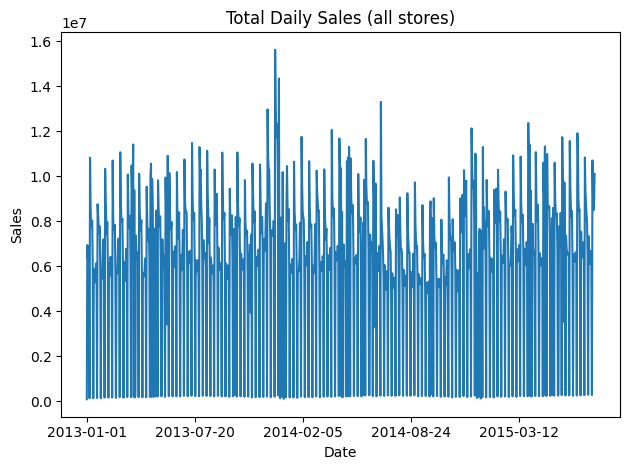

In [30]:
daily_total = train.groupby('Date').Sales.sum()
ax = daily_total.plot(title='Total Daily Sales (all stores)', xlabel='Date', ylabel='Sales')
plt.tight_layout(); plt.show()


In [31]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [41]:
promo1 = train[train.Open == 1].groupby('Promo').Sales.mean().round(0)
promo1.round(2)

Promo
0    5929.0
1    8228.0
Name: Sales, dtype: float64

In [38]:
store = pd.read_csv('store.csv')
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [39]:
store.isna().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [40]:
store.shape

(1115, 10)

In [ ]:
tr = train[(train.Open == 1) & (train.Sales > 0)].copy()


daily = (tr.groupby('Date')
           .agg(Sales=('Sales','sum'),
                n_open=('Store','nunique'),
                Promo=('Promo','mean'))     
           .reset_index())

# Prophet format
series = daily.rename(columns={'Date':'ds', 'Sales':'y'})[['ds','y','n_open','Promo']]
print(series.shape)
series.head()

(942, 4)


,ds,y,n_open,Promo
0,2013-01-01,97235,17,0.0
1,2013-01-02,6949829,1111,0.0
2,2013-01-03,6347820,1109,0.0
3,2013-01-04,6638954,1108,0.0
4,2013-01-05,5951593,1107,0.0


In [52]:
series['ds'] = pd.to_datetime(series['ds'])
series.info()

<class 'pandas.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      942 non-null    datetime64[us]
 1   y       942 non-null    int64         
 2   n_open  942 non-null    int64         
 3   Promo   942 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 29.6 KB


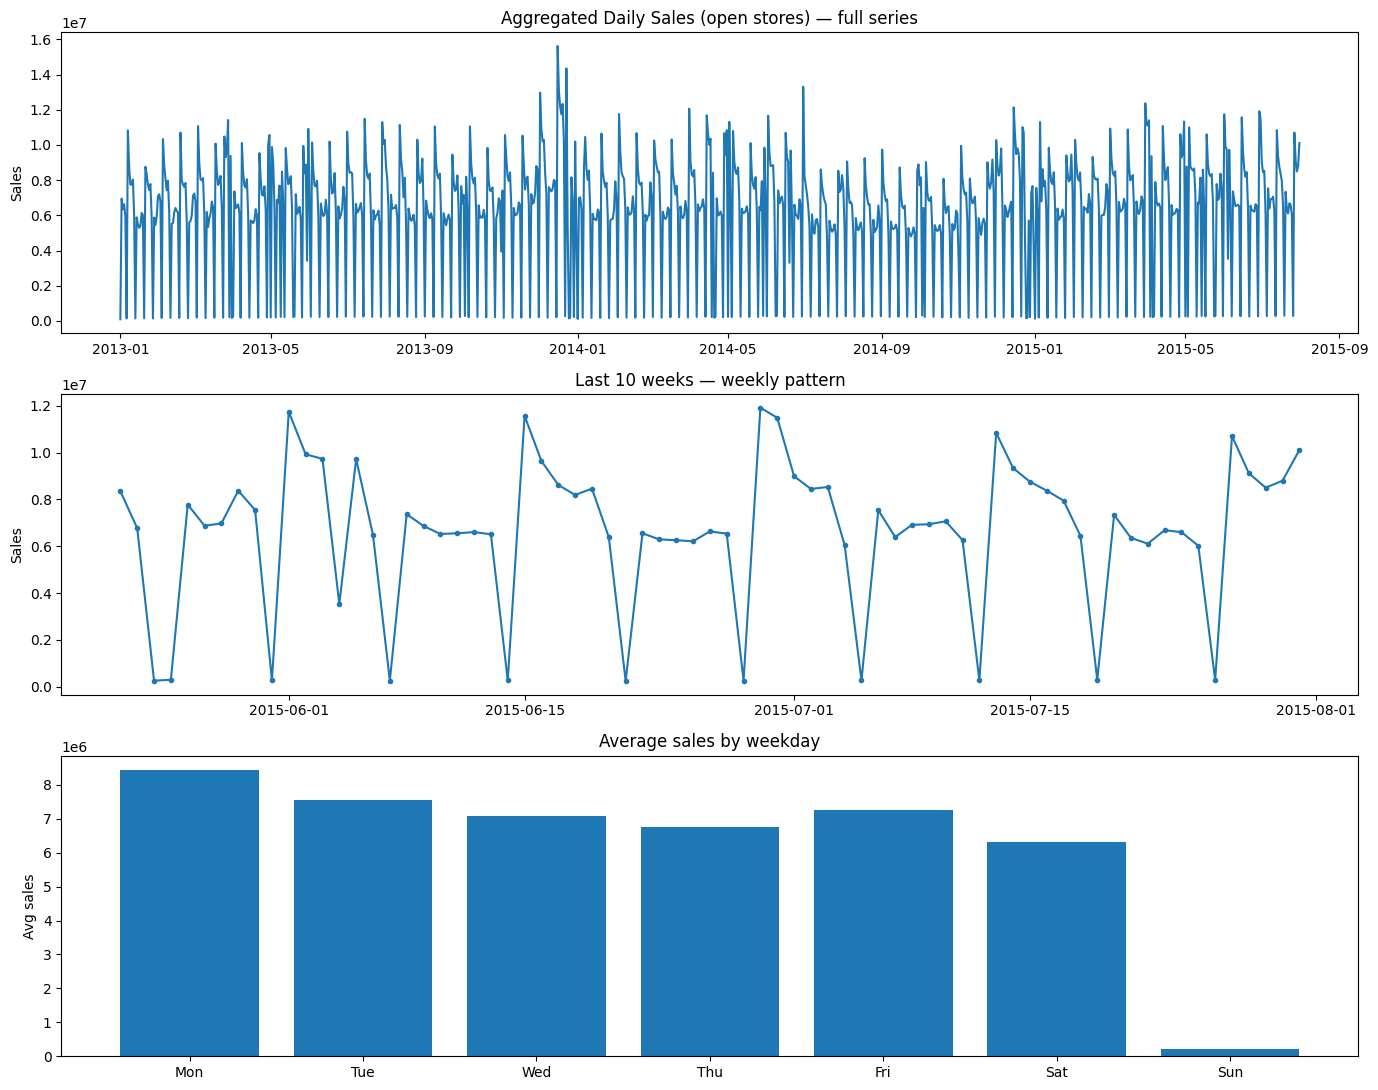

Weekday averages (Mon->Sun):
[8434351. 7558607. 7073799. 6749465. 7263377. 6315804.  220533.]

December avg: 6,997,277  vs  yearly avg: 6,234,799


In [53]:
# ---- Plot aggregated series + confirm seasonality ----
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# (a) Full series over time -> yearly seasonality + trend
axes[0].plot(series.ds, series.y)
axes[0].set_title('Aggregated Daily Sales (open stores) — full series')
axes[0].set_ylabel('Sales')

# (b) Zoom to ~10 weeks -> weekly cycle becomes obvious
zoom = series[series.ds >= series.ds.max() - pd.Timedelta(days=70)]
axes[1].plot(zoom.ds, zoom.y, marker='o', ms=3)
axes[1].set_title('Last 10 weeks — weekly pattern')
axes[1].set_ylabel('Sales')

# (c) Average by weekday -> quantifies the weekly shape
by_dow = series.assign(dow=series.ds.dt.dayofweek).groupby('dow').y.mean()
axes[2].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], by_dow.values)
axes[2].set_title('Average sales by weekday')
axes[2].set_ylabel('Avg sales')

plt.tight_layout(); plt.show()

# Numeric confirmation
print('Weekday averages (Mon->Sun):')
print(by_dow.round(0).values)
print(f'\nDecember avg: {series[series.ds.dt.month==12].y.mean():,.0f}'
      f'  vs  yearly avg: {series.y.mean():,.0f}')

In [ ]:
#burdann gore bilirik ki Her Monday satislarin en cox oldugu gundur hefte icinde

In [56]:
HORIZON = 48  
series['ds'] = pd.to_datetime(series['ds'])          
split_date = series['ds'].max() - pd.Timedelta(days=HORIZON)

train_s = series[series['ds'] <= split_date].copy()
valid_s = series[series['ds'] >  split_date].copy()
print('train_s:', train_s.ds.min().date(), '->', train_s.ds.max().date(), len(train_s))
print('valid_s:', valid_s.ds.min().date(), '->', valid_s.ds.max().date(), len(valid_s))

train_s: 2013-01-01 -> 2015-06-13 894
valid_s: 2015-06-14 -> 2015-07-31 48


In [57]:
sh = train.copy()
sh['StateHoliday'] = sh['StateHoliday'].astype(str)  
state_days = sh[sh['StateHoliday'].isin(['a','b','c'])]['Date'].unique()

holidays = pd.DataFrame({
    'holiday': 'state_holiday',
    'ds': pd.to_datetime(pd.Series(state_days)),
    'lower_window': 0,
    'upper_window': 0,
})
print(f'{len(holidays)} state-holiday dates')


assert 'Promo' in train_s.columns, "Promo column missing — merge it from `series`"

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays,
)
m.add_regressor('Promo')
m.fit(train_s[['ds', 'y', 'Promo']])

21:57:10 - cmdstanpy - INFO - Chain [1] start processing


37 state-holiday dates


21:57:10 - cmdstanpy - INFO - Chain [1] done processing


In [58]:
future = m.make_future_dataframe(periods=HORIZON, freq='D')
future = future.merge(series[['ds', 'Promo']], on='ds', how='left')
future['Promo'] = future['Promo'].fillna(0)   
forecast = m.predict(future)

In [61]:
prophet_pred = forecast[['ds','yhat']].merge(series[['ds','y']], on='ds', how='right')
prophet_pred.tail()

,ds,yhat,y
937,2015-07-27,9.933209e+06,10707292
938,2015-07-28,8.868748e+06,9115073
939,2015-07-29,8.523746e+06,8499962
940,2015-07-30,8.528830e+06,8798854
941,2015-07-31,8.851690e+06,10109742


In [62]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Promo,Promo_lower,Promo_upper,additive_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,5.161130e+06,-9.062657e+04,2.479932e+06,5.161130e+06,5.161130e+06,0.000000e+00,0.000000e+00,0.000000e+00,-3.945360e+06,...,8.024063e+05,8.024063e+05,8.024063e+05,664485.372807,664485.372807,664485.372807,0.0,0.0,0.0,1.215770e+06
1,2013-01-02,5.163804e+06,4.914773e+06,7.454850e+06,5.163804e+06,5.163804e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.026759e+06,...,4.528005e+05,4.528005e+05,4.528005e+05,573958.474577,573958.474577,573958.474577,0.0,0.0,0.0,6.190563e+06
2,2013-01-03,5.166479e+06,4.841695e+06,7.407662e+06,5.166479e+06,5.166479e+06,0.000000e+00,0.000000e+00,0.000000e+00,9.389865e+05,...,4.527286e+05,4.527286e+05,4.527286e+05,486257.970081,486257.970081,486257.970081,0.0,0.0,0.0,6.105465e+06
3,2013-01-04,5.169153e+06,5.047144e+06,7.640632e+06,5.169153e+06,5.169153e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.172081e+06,...,7.698109e+05,7.698109e+05,7.698109e+05,402270.181362,402270.181362,402270.181362,0.0,0.0,0.0,6.341234e+06
4,2013-01-05,5.171828e+06,5.078993e+06,7.702903e+06,5.171828e+06,5.171828e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.195707e+06,...,8.729359e+05,8.729359e+05,8.729359e+05,322771.275185,322771.275185,322771.275185,0.0,0.0,0.0,6.367535e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937,2015-07-27,6.027687e+06,8.696076e+06,1.125574e+07,6.010911e+06,6.043780e+06,2.466973e+06,2.466973e+06,2.466973e+06,3.905522e+06,...,1.870991e+06,1.870991e+06,1.870991e+06,-432441.659853,-432441.659853,-432441.659853,0.0,0.0,0.0,9.933209e+06
938,2015-07-28,6.031465e+06,7.596644e+06,1.018869e+07,6.014128e+06,6.048259e+06,2.466973e+06,2.466973e+06,2.466973e+06,2.837283e+06,...,8.024063e+05,8.024063e+05,8.024063e+05,-432095.765587,-432095.765587,-432095.765587,0.0,0.0,0.0,8.868748e+06
939,2015-07-29,6.035243e+06,7.178907e+06,9.809095e+06,6.017163e+06,6.052969e+06,2.466973e+06,2.466973e+06,2.466973e+06,2.488503e+06,...,4.528005e+05,4.528005e+05,4.528005e+05,-431270.091711,-431270.091711,-431270.091711,0.0,0.0,0.0,8.523746e+06
940,2015-07-30,6.039021e+06,7.329853e+06,9.836293e+06,6.020281e+06,6.057313e+06,2.466973e+06,2.466973e+06,2.466973e+06,2.489809e+06,...,4.527286e+05,4.527286e+05,4.527286e+05,-429892.009486,-429892.009486,-429892.009486,0.0,0.0,0.0,8.528830e+06


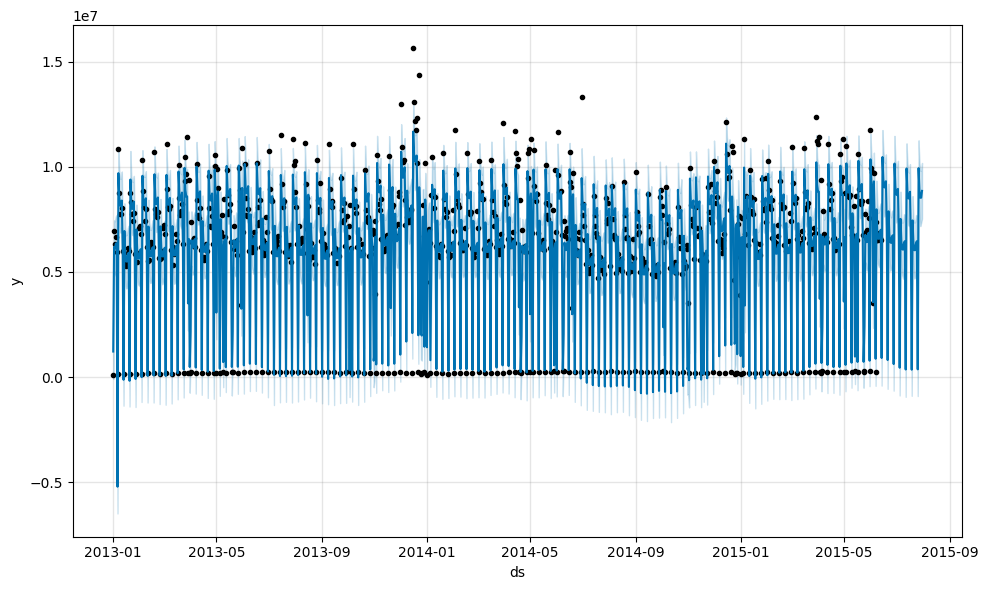

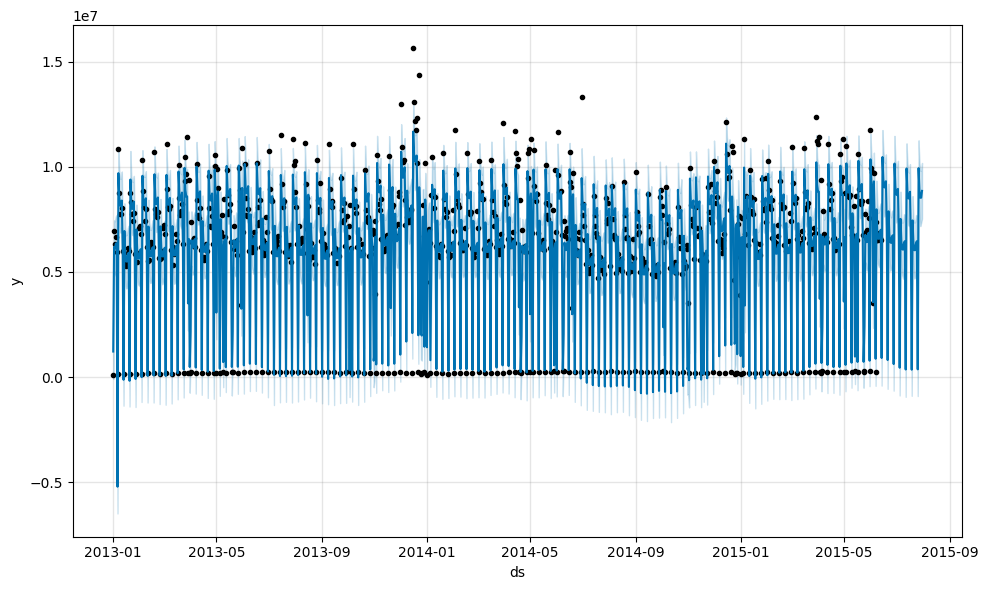

In [63]:
m.plot(forecast)

In [65]:
pv = prophet_pred[prophet_pred.ds > split_date].dropna(subset=['y', 'yhat'])

In [67]:
pv.head()

,ds,yhat,y
894,2015-06-14,9.076378e+05,269533
895,2015-06-15,1.046212e+07,11570100
896,2015-06-16,9.385405e+06,9636747
897,2015-06-17,9.024695e+06,8618478
898,2015-06-18,9.010613e+06,8191358


In [69]:
mae_prophet = mean_absolute_error(pv.y, pv.yhat)
mae_prophet.__round__(2)

487748.68

In [101]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [102]:
mape_prophet = mape(pv.y, pv.yhat)
mape_prophet.round(2)

np.float64(20.75)

In [103]:
resid_df = prophet_pred.copy()
resid_df['residual'] = resid_df['y'] - resid_df['yhat']


resid_df = resid_df.merge(series[['ds','n_open','Promo']], on='ds', how='left')

resid_df['dow']   = resid_df['ds'].dt.dayofweek
resid_df['month'] = resid_df['ds'].dt.month
resid_df['week']  = resid_df['ds'].dt.isocalendar().week.astype(int)
resid_df['day']   = resid_df['ds'].dt.day
resid_df.head()

,ds,yhat,y,residual,n_open,Promo,dow,month,week,day
0,2013-01-01,1.215770e+06,97235,-1.118535e+06,17,0.0,1,1,1,1
1,2013-01-02,6.190563e+06,6949829,7.592657e+05,1111,0.0,2,1,1,2
2,2013-01-03,6.105465e+06,6347820,2.423547e+05,1109,0.0,3,1,1,3
3,2013-01-04,6.341234e+06,6638954,2.977197e+05,1108,0.0,4,1,1,4
4,2013-01-05,6.367535e+06,5951593,-4.159418e+05,1107,0.0,5,1,1,5


In [104]:
tr = train[(train.Open == 1) & (train.Sales > 0)].copy()
tr['StateHoliday'] = tr['StateHoliday'].astype(str)

In [105]:
tr = train[(train.Open == 1) & (train.Sales > 0)].copy()
tr['StateHoliday'] = tr['StateHoliday'].astype(str)


tr = tr.merge(store, on='Store', how='left')
tr['CompetitionDistance'] = tr['CompetitionDistance'].fillna(tr['CompetitionDistance'].median())

daily = tr.groupby('Date').agg(
    Sales        =('Sales', 'sum'),
    n_open       =('Store', 'nunique'),
    Promo        =('Promo', 'mean'),
    school_frac  =('SchoolHoliday', 'mean'),
    comp_dist    =('CompetitionDistance', 'mean'),
    promo2_share =('Promo2', 'mean'),
    typea_share  =('StoreType', lambda s: (s == 'a').mean()),
).reset_index()

state_flag = (tr.assign(is_sh=tr.StateHoliday != '0')
                .groupby('Date')['is_sh'].any().astype(int)
                .rename('state_flag'))
daily = daily.merge(state_flag, on='Date', how='left')

series = daily.rename(columns={'Date': 'ds', 'Sales': 'y'})
series['ds'] = pd.to_datetime(series['ds'])
print(series.shape)

(942, 9)


In [106]:
series.head()

,ds,y,n_open,Promo,school_frac,comp_dist,promo2_share,typea_share,state_flag
0,2013-01-01,97235,17,0.0,1.000000,2105.294118,0.294118,0.058824,1
1,2013-01-02,6949829,1111,0.0,1.000000,5408.487849,0.513051,0.541854,0
2,2013-01-03,6347820,1109,0.0,0.932372,5414.463481,0.513075,0.541930,0
3,2013-01-04,6638954,1108,0.0,0.932310,5418.817690,0.512635,0.542419,0
4,2013-01-05,5951593,1107,0.0,0.100271,5403.396567,0.513098,0.542005,0


In [107]:
features_for_res = ['n_open','Promo','dow','month','week','day'] 

train_x = resid_df[resid_df.ds <= split_date]
valid_x = resid_df[resid_df.ds >  split_date]

Xtr, ytr = train_x[features_for_res], train_x['residual']
Xva, yva = valid_x[features_for_res], valid_x['residual']

In [108]:
xgb_resid = xgb.XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)
xgb_resid.fit(Xtr, ytr)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [109]:
valid_x['resid_pred'] = xgb_resid.predict(Xva)
valid_x['hybrid'] = valid_x['yhat'] + valid_x['resid_pred']

In [110]:
mae_hybrid = mean_absolute_error(valid_x.y, valid_x.hybrid)
mae_hybrid.__round__(2)

425785.16

In [111]:
mape_hybrid = np.abs(np.mean((valid_x.y - valid_x.hybrid) / valid_x.y))

In [112]:
mape_hybrid.round(2)
#Leakage oldu

np.float64(0.22)

In [113]:
xgb_only = xgb.XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)
xgb_only.fit(train_x[features_for_res], train_x['y'])

valid_x['xgb_only'] = xgb_only.predict(Xva)

In [114]:
mae_xgb = mean_absolute_error(valid_x.y, valid_x.xgb_only)
mae_xgb

366416.78125

In [115]:
mape_xgb = np.abs(np.mean((valid_x.y - valid_x.hybrid) / valid_x.y))
mape_xgb.round(2)

np.float64(0.22)

In [ ]:
v = valid_x.dropna(subset=['y','yhat','hybrid','xgb_only'])

mae_prophet  = mean_absolute_error(v['y'], v['yhat'])
mape_prophet = mape(v['y'], v['yhat'])

mae_hybrid   = mean_absolute_error(v['y'], v['hybrid'])
mape_hybrid  = mape(v['y'], v['hybrid'])

mae_xgb      = mean_absolute_error(v['y'], v['xgb_only'])
mape_xgb     = mape(v['y'], v['xgb_only'])

results = pd.DataFrame({
    'Model': ['Prophet only', 'XGBoost only', 'Hybrid (Prophet+XGB)'],
    'MAE':   [mae_prophet, mae_xgb, mae_hybrid],
    'MAPE':  [mape_prophet, mape_xgb, mape_hybrid],
}).sort_values('MAE').reset_index(drop=True)

results.round(2)

,Model,MAE,MAPE
0,XGBoost only,366416.78,6.89
1,Hybrid (Prophet+XGB),425785.16,23.98
2,Prophet only,487748.68,20.75


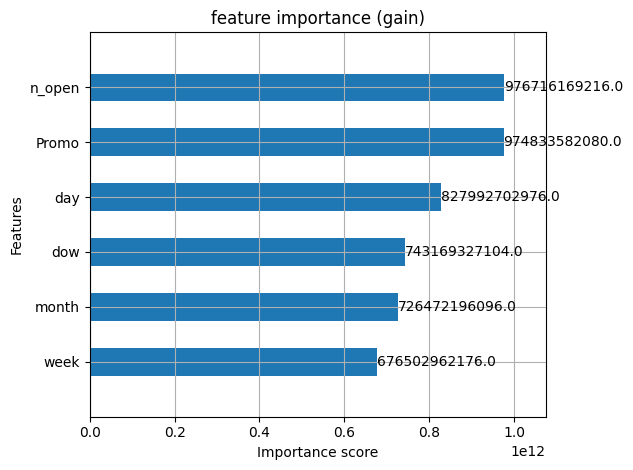

In [132]:
xgb.plot_importance(xgb_resid, importance_type='gain', height=0.5)
plt.title('feature importance (gain)')
plt.tight_layout()
plt.show()

In [122]:
imp = (pd.Series(xgb_resid.feature_importances_, index=features_for_res)
         .sort_values(ascending=False))
print(imp.round(3))

n_open    0.198
Promo     0.198
day       0.168
dow       0.151
month     0.147
week      0.137
dtype: float32
